# MatchIQ UCL v4 — Audit dan perbaikan pra-pertandingan

Revisi dari **file terbaru Anda**, `MatchIQ_UCL_Hybrid_AI_Colab_v3_optimized.ipynb`, beserta output September 12, 2026. Gunakan `data.zip` UCL yang sama. **Colab → Python / CPU → Run all**. File model, laporan CSV/JSON, dan plot dikemas otomatis.

## Temuan yang mengubah penilaian model sebelumnya

| Temuan | Bukti dari file terbaru | Perbaikan |
|---|---|---|
| Kebocoran skor babak pertama | `home_goals_ht`, `away_goals_ht` masuk MODEL_FEATURES; importance +0,2283 dan +0,1642 log loss | Hapus seluruh informasi pertandingan yang belum tersedia sebelum kick-off |
| Training dan inference berbeda | Skor HT aktual pada training, nilai fallback 0,5 pada prediksi | Satu fungsi fitur dan pengujian parity |
| Elo produksi salah | Mengambil `home_elo_pre` pada baris terakhir termasuk laga tandang | Simpan state setiap klub setelah pembaruan terakhir |
| Kalibrasi tidak konsisten | Kelas kalibrasi dibuat tetapi fungsi prediksi dan bundle memakai blend mentah | Jalur inference dan ekspor memakai kalibrator terpilih |
| Evaluasi belum nested | Tiga musim tuning dilaporkan bersama final holdout; CV kalibrasi biasa | Outer test terpisah dari meta training, tuning, dan kalibrasi |

**Akurasi 64,55%, log loss 0,8156, dan ECE 9,43% dari output lama tidak valid sebagai benchmark pra-pertandingan**, karena dua fitur paling dominan baru tersedia saat jeda babak pertama. Menghapus leakage dapat menurunkan angka yang dilaporkan sambil memperbaiki validitas model.

Tidak ada target akurasi yang dipaksakan. Hasil setiap eksperimen, termasuk yang gagal meningkatkan performa, tetap dilaporkan. Musim yang telah dilihat pada eksperimen terdahulu merupakan backtest riset, bukan konfirmasi prospektif baru.

## Hasil pengujian revisi ini

Eksekusi seluruh cell berhasil pada dataset UCL 1.997 laga. Empat outer season mencakup 628 pertandingan. Hasil lokal ini disertakan sebagai output notebook; Run all menghitung ulang semuanya.

| Mode | Accuracy | Macro-F1 | Draw recall | ECE confidence |
|---|---:|---:|---:|---:|
| Probabilitas tertinggi (argmax) | 56,21% | 0,4040 | 0,00% | 2,73% |
| Label draw-aware | 52,71% | 0,4606 | 22,12% | 2,73% |

Log loss model utama 0,9399 vs Dixon–Coles 1,0024 pada split yang sama. Paired bootstrap selisih log loss -0,0625 (95% CI -0,0897 sampai -0,0374). Perbandingan ini tidak setara dengan model lama yang memakai skor HT aktual.

**Penilaian:** implementasi dan evaluasi sudah lebih dapat diaudit untuk demo/riset. Deteksi Draw masih lemah: argmax tidak mengenali satu pun seri dengan benar; policy menaikkan recall tetapi precision seri hanya 20,16% dan akurasi turun 3,50 poin persentase pada outer test. Batas 3 poin pada tuning bukan jaminan pada data test. Belum ada bukti prospektif untuk menyebut model sangat kuat atau siap dipakai mengandalkan hasilnya.

Untuk musim terakhir 2025–26 saja (189 laga), argmax accuracy 54,50%, ECE 7,76%; policy accuracy 52,91% dan Draw recall 38,24%. Agregat ECE yang lebih rendah tidak berarti setiap musim sudah terkalibrasi sama baiknya.


## 0. Dependency dan konfigurasi

In [1]:
import importlib.util,subprocess,sys
try:IN_COLAB=importlib.util.find_spec('google.colab') is not None
except ModuleNotFoundError:IN_COLAB=False
if IN_COLAB:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','xgboost==3.0.5','scikit-learn==1.8.0','Jinja2','joblib','matplotlib','pandas','scipy'])


In [2]:
from __future__ import annotations

import json
import math
import platform
import shutil
import warnings
import zipfile
from collections import Counter
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from IPython.display import clear_output, display
from scipy.optimize import minimize
from scipy.special import gammaln

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_SEED = 42
MAX_GOALS = 7
WALK_FORWARD_SEASONS = ["2022-23", "2023-24", "2024-25", "2025-26"]
BLEND_TUNING_SEASONS = WALK_FORWARD_SEASONS[:-1]
FINAL_HOLDOUT_SEASON = WALK_FORWARD_SEASONS[-1]
BLEND_OBJECTIVE = "log_loss"  # pilihan: log_loss atau brier
BOOTSTRAP_REPEATS = 1_000
STRICT_EXPECTED_COUNTS = True

print(f"Python       : {platform.python_version()}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"XGBoost      : {xgboost.__version__}")
print(f"Colab        : {IN_COLAB}")


Python       : 3.12.10
pandas       : 3.0.5
scikit-learn : 1.9.0
XGBoost      : 3.4.1
Colab        : False


## 1. Dataset dan validasi

In [3]:
ZIP_FILENAME = "data.zip"
REQUIRED_DATA_FILES = ["ucl_matches.csv", "ucl_matches_all.csv", "ucl_teams.csv", "ucl_team_aliases.csv"]
candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((root for root in candidate_roots if all((root / "data" / "processed" / name).is_file() for name in REQUIRED_DATA_FILES)), None)
LOCAL_DATA_DIR = PROJECT_ROOT / "data" / "processed" if PROJECT_ROOT else None
search_locations = [Path("/content") / ZIP_FILENAME]
for root in candidate_roots:
    search_locations.extend([root / ZIP_FILENAME, root / "data" / ZIP_FILENAME])
DATA_ZIP_PATH = None if LOCAL_DATA_DIR else next((path for path in search_locations if path.is_file()), None)

if LOCAL_DATA_DIR is None and DATA_ZIP_PATH is None:
    if not IN_COLAB:
        raise FileNotFoundError(
            "Dataset UCL tidak ditemukan. Jalankan notebook dari root MatchIQ yang memiliki data/processed, atau sediakan data.zip."
        )
    from google.colab import files

    print("Pilih dan upload file data.zip...")
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("Upload dibatalkan.")
    uploaded_zip_names = [name for name in uploaded if name.lower().endswith(".zip")]
    if not uploaded_zip_names:
        raise ValueError("File yang diupload bukan ZIP.")
    DATA_ZIP_PATH = Path("/content") / uploaded_zip_names[0]

if LOCAL_DATA_DIR is not None:
    WORK_ROOT = PROJECT_ROOT / "outputs" / "ucl_v4_notebook"
    EXTRACT_DIR = LOCAL_DATA_DIR
    OUTPUT_DIR = WORK_ROOT / "artifacts"
else:
    WORK_ROOT = Path("/content/matchiq_ucl_v4_colab") if IN_COLAB else Path.cwd() / "matchiq_ucl_v4_colab"
    EXTRACT_DIR = WORK_ROOT / "dataset"
    OUTPUT_DIR = WORK_ROOT / "outputs"
    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def safe_extract(archive_path: Path, destination: Path) -> None:
    destination = destination.resolve()
    with zipfile.ZipFile(archive_path) as archive:
        bad_member = archive.testzip()
        if bad_member:
            raise ValueError(f"ZIP rusak pada file: {bad_member}")
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if destination not in target.parents and target != destination:
                raise ValueError(f"Path ZIP tidak aman: {member.filename}")
        archive.extractall(destination)


if DATA_ZIP_PATH is not None:
    safe_extract(DATA_ZIP_PATH, EXTRACT_DIR)


def find_exactly_one(filename: str) -> Path:
    candidates = list(EXTRACT_DIR.rglob(filename))
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Diharapkan satu {filename}, ditemukan {len(candidates)}: {candidates}"
        )
    return candidates[0]


MATCHES_PATH = find_exactly_one("ucl_matches.csv")
ALL_MATCHES_PATH = find_exactly_one("ucl_matches_all.csv")
TEAMS_PATH = find_exactly_one("ucl_teams.csv")
ALIASES_PATH = find_exactly_one("ucl_team_aliases.csv")

print(f"[OK] Source    : {LOCAL_DATA_DIR or DATA_ZIP_PATH}")
print(f"[OK] Dataset   : {MATCHES_PATH.relative_to(EXTRACT_DIR)}")
print(f"[OK] Output    : {OUTPUT_DIR}")


[OK] Source    : D:\Projects\MatchIQ\data\processed
[OK] Dataset   : ucl_matches.csv
[OK] Output    : D:\Projects\MatchIQ\outputs\ucl_v4_notebook\artifacts


In [4]:
raw_matches = pd.read_csv(MATCHES_PATH)
all_matches = pd.read_csv(ALL_MATCHES_PATH)
teams = pd.read_csv(TEAMS_PATH)
aliases = pd.read_csv(ALIASES_PATH)

required_columns = [
    "match_id", "season", "date", "stage", "leg", "neutral",
    "home_team", "away_team", "home_goals", "away_goals", "result",
]
missing_columns = sorted(set(required_columns) - set(raw_matches.columns))
if missing_columns:
    raise ValueError(f"Kolom wajib hilang: {missing_columns}")

raw_matches["date"] = pd.to_datetime(raw_matches["date"], errors="coerce")
for column in ["home_goals", "away_goals"]:
    raw_matches[column] = pd.to_numeric(raw_matches[column], errors="coerce")

missing_values = int(raw_matches[required_columns].isna().sum().sum())
duplicate_ids = int(raw_matches["match_id"].duplicated().sum())
invalid_scores = int(
    ((raw_matches["home_goals"] < 0) | (raw_matches["away_goals"] < 0)).sum()
)

audit = pd.DataFrame(
    [
        ("Kolom wajib hilang", 0, len(missing_columns)),
        ("Nilai wajib kosong", 0, missing_values),
        ("Match ID duplikat", 0, duplicate_ids),
        ("Skor negatif", 0, invalid_scores),
        ("Pertandingan utama", 1997, len(raw_matches)),
        ("Pertandingan termasuk kualifikasi", 2179, len(all_matches)),
        ("Klub kanonis", 161, teams["team_name"].nunique()),
        ("Musim", 15, raw_matches["season"].nunique()),
    ],
    columns=["Pemeriksaan", "Ekspektasi", "Aktual"],
)
audit["Status"] = np.where(audit["Ekspektasi"] == audit["Aktual"], "PASS", "FAIL")
display(audit)

assert missing_values == 0
assert duplicate_ids == 0
assert invalid_scores == 0
if STRICT_EXPECTED_COUNTS:
    assert (audit["Status"] == "PASS").all(), "Cakupan data berbeda dari paket teruji."

matches = raw_matches[required_columns].copy()
matches["home_goals"] = matches["home_goals"].astype(int)
matches["away_goals"] = matches["away_goals"].astype(int)
matches["stage"] = matches["stage"].astype(str)
matches["leg"] = matches["leg"].astype(str)
matches["neutral"] = pd.to_numeric(matches["neutral"], errors="coerce").fillna(0).astype(int)
matches = matches.sort_values(
    ["date", "match_id"], kind="stable"
).reset_index(drop=True)

summary = pd.Series(
    {
        "Pertandingan utama": len(matches),
        "Klub kanonis": teams["team_name"].nunique(),
        "Musim": matches["season"].nunique(),
        "Tanggal awal": matches["date"].min().date(),
        "Tanggal akhir": matches["date"].max().date(),
    },
    name="UCL dataset",
)
display(summary.to_frame())
display(matches.head())

expected=np.where(matches.home_goals>matches.away_goals,'H',np.where(matches.home_goals==matches.away_goals,'D','A'))
assert np.array_equal(expected,matches.result)
assert not matches.duplicated(['date','home_team','away_team']).any()


,Pemeriksaan,Ekspektasi,Aktual,Status
0,Kolom wajib hilang,0,0,PASS
1,Nilai wajib kosong,0,0,PASS
2,Match ID duplikat,0,0,PASS
3,Skor negatif,0,0,PASS
4,Pertandingan utama,1997,1997,PASS
5,Pertandingan termasuk kualifikasi,2179,2179,PASS
6,Klub kanonis,161,161,PASS
7,Musim,15,15,PASS


,UCL dataset
Pertandingan utama,1997
Klub kanonis,161
Musim,15
Tanggal awal,2011-09-13
Tanggal akhir,2026-05-30


,match_id,season,date,stage,leg,neutral,home_team,away_team,home_goals,away_goals,result
0,UCL-2011-12-M-0001,2011-12,2011-09-13,group_stage,not_applicable,0,Chelsea FC,Bayer Leverkusen,2,0,H
1,UCL-2011-12-M-0002,2011-12,2011-09-13,group_stage,not_applicable,0,KRC Genk,Valencia CF,0,0,D
2,UCL-2011-12-M-0003,2011-12,2011-09-13,group_stage,not_applicable,0,Borussia Dortmund,Arsenal FC,1,1,D
3,UCL-2011-12-M-0004,2011-12,2011-09-13,group_stage,not_applicable,0,Olympiacos,Olympique Marseille,0,1,A
4,UCL-2011-12-M-0005,2011-12,2011-09-13,group_stage,not_applicable,0,APOEL Nikosia,Zenit St. Petersburg,2,1,H


## 2. State tim, H2H dan fitur sebelum pertandingan

H2H memakai decay dua tahun dan smoothing terhadap draw rate historis. Elo mempertahankan stage-aware K serta menerapkan leg, margin dan venue secara konsisten. Tambahan statistik gol/form berasal dari laga sebelumnya, dengan shrinkage untuk klub berhistori pendek. Proxy gol bukan statistik xG berbasis tembakan.

Seluruh pertandingan pada satu tanggal mendapat fitur sebelum hasil tanggal tersebut memperbarui state. Uji otomatis memastikan perubahan hasil sekarang/masa depan tidak mengubah fitur sebelumnya, dan fungsi prediksi menghasilkan fitur yang sama dengan training.

In [5]:
from collections import defaultdict
import copy, hashlib

H2H_HALF_LIFE_DAYS=730.0
H2H_PRIOR_STRENGTH=5.0
ELO_K_FACTORS={'group_stage':24.,'league_phase':24.,'playoff':28.,'round_of_16':32.,
    'quarterfinal':36.,'semifinal':40.,'final':48.}
STAGES=list(ELO_K_FACTORS)

def new_state():
    return dict(teams={},pairs={},draws=0,n=0,last_date=None)

def team_state(state,name):
    return state['teams'].get(name,dict(elo=1500.,games=[],last_date=None))

def weighted_stat(games,key,window=10,prior=1.3,strength=3.):
    values=[g[key] for g in games[-window:]]
    if not values:return prior
    w=np.power(.85,np.arange(len(values)-1,-1,-1))
    return float((np.dot(w,values)+strength*prior)/(w.sum()+strength))

def match_features(state,home,away,date,stage,leg,neutral):
    date=pd.Timestamp(date); h=team_state(state,home);a=team_state(state,away)
    neutral=int(neutral);leg=str(leg).replace('.0','')
    prior=(state['draws']+5)/(state['n']+25)
    hg,ag=h['games'],a['games']
    values=dict(neutral=neutral,home_elo_pre=h['elo'],away_elo_pre=a['elo'],
        elo_diff_pre=h['elo']-a['elo'],abs_elo_diff=abs(h['elo']-a['elo']),
        is_knockout=int(stage not in ['group_stage','league_phase']),
        leg_first=int(leg in ['1','first']),leg_second=int(leg in ['2','second']),
        leg_single=int(leg=='single'))
    for prefix,t,other in [('h',h,a),('a',a,h)]:
        g=t['games']
        values[prefix+'_history']=min(len(g),40)
        values[prefix+'_rest_days']=min((date-t['last_date']).days,90) if t['last_date'] is not None else 90
        for size in [5,10]:
            for key,prior_value in [('gs',1.3),('gc',1.3),('points',1.3),('draw',prior)]:
                values[f'{prefix}_{key}_{size}']=weighted_stat(g,key,size,prior_value)
        values[prefix+'_goal_variance']=float(np.var([v['gs'] for v in g[-10:]])) if len(g)>=3 else 1.3
    values['xg_proxy_home']=np.clip((values['h_gs_10']+values['a_gc_10'])/2+.15*(1-neutral),.2,5)
    values['xg_proxy_away']=np.clip((values['a_gs_10']+values['h_gc_10'])/2,.2,5)
    values['xg_total']=values['xg_proxy_home']+values['xg_proxy_away']
    values['xg_abs_diff']=abs(values['xg_proxy_home']-values['xg_proxy_away'])
    values['draw_balance']=np.exp(-values['xg_abs_diff']-values['abs_elo_diff']/300)/(1+np.exp(values['xg_total']-2.5))
    history=state['pairs'].get(tuple(sorted([home,away])),[])
    weights=[(2**(-(date-d).days/H2H_HALF_LIFE_DAYS),dr) for d,dr in history
        if d<date and (date-d).days<=3650]
    effective=sum(w for w,d in weights)
    values['h2h_effective_meetings']=effective
    values['h2h_weighted_draw_rate']=(sum(w*d for w,d in weights)+prior*H2H_PRIOR_STRENGTH)/(effective+H2H_PRIOR_STRENGTH)
    values.update({f'stage_{s}':int(stage==s) for s in STAGES})
    return values

def update_state(state,row):
    home,away=row.home_team,row.away_team;date=pd.Timestamp(row.date)
    for t in [home,away]:
        if t not in state['teams']:state['teams'][t]=dict(elo=1500.,games=[],last_date=None)
    h,a=state['teams'][home],state['teams'][away]
    hg,ag=int(row.home_goals),int(row.away_goals);dr=int(hg==ag)
    exp=1/(1+10**((a['elo']-h['elo']-70*(1-int(row.neutral)))/400))
    actual=1. if hg>ag else (.5 if dr else 0.)
    leg=str(row.leg).replace('.0','');leg_mult=.85 if leg in ['1','first'] else (1.15 if leg in ['2','second'] else 1.)
    # Margin/stage influence only updates ratings for subsequent fixtures.
    margin=min(1.6,1+np.log1p(abs(hg-ag))/3)
    shift=ELO_K_FACTORS.get(row.stage,24.)*leg_mult*margin*(actual-exp)
    h['elo']+=shift;a['elo']-=shift
    for t,gs,gc in [(h,hg,ag),(a,ag,hg)]:
        t['games'].append(dict(gs=gs,gc=gc,draw=dr,points=3 if gs>gc else (1 if dr else 0)))
        t['last_date']=date
    state['pairs'].setdefault(tuple(sorted([home,away])),[]).append((date,dr))
    state['draws']+=dr;state['n']+=1;state['last_date']=date

def make_features(frame):
    frame=frame.sort_values(['date','match_id']).reset_index(drop=True)
    state=new_state();rows=[]
    # All fixtures on a date are scored before any result on that date is added.
    for date,day in frame.groupby('date',sort=True):
        for r in day.itertuples():
            rows.append(match_features(state,r.home_team,r.away_team,r.date,r.stage,r.leg,r.neutral))
        for r in day.itertuples():update_state(state,r)
    features=pd.DataFrame(rows)
    overlap=[c for c in features if c in frame]
    return frame.drop(columns=overlap).join(features),state

professional,final_state=make_features(matches)
FEATURES=list(match_features(new_state(),'A','B',matches.date.min(),'group_stage','not_applicable',0))
FORBIDDEN={'home_goals_ht','away_goals_ht','home_goals','away_goals','result','total_goals',
    'home_goals_final','away_goals_final','home_penalty','away_penalty','score_raw','goal_diff','btts'}
assert not FORBIDDEN.intersection(FEATURES)
assert np.isfinite(professional[FEATURES].to_numpy()).all()
H2H=[c for c in FEATURES if c.startswith('h2h_')]
CONTEXT=[c for c in FEATURES if c.startswith('stage_') or c.startswith('leg_') or c in ['is_knockout','neutral']]
DRAW_SIGNALS=['abs_elo_diff','xg_abs_diff','xg_total','draw_balance']
COMPACT=['neutral','elo_diff_pre','abs_elo_diff','h_gs_10','h_gc_10','a_gs_10','a_gc_10',
    'h_points_10','a_points_10','h_draw_10','a_draw_10','xg_total','xg_abs_diff','draw_balance']+H2H
FEATURE_SETS={'full':FEATURES,'compact':COMPACT,'no_h2h':[c for c in FEATURES if c not in H2H]}

# Causality check: changing current/future labels cannot alter earlier features.
cut=int(np.flatnonzero(matches.date.ne(matches.date.shift()).to_numpy())[10])
modified=matches.iloc[:max(100,cut+10)].copy()
modified.loc[cut:,'home_goals']=7;modified.loc[cut:,'away_goals']=0;modified.loc[cut:,'result']='H'
changed,_=make_features(modified)
assert np.allclose(changed.loc[:cut,FEATURES],professional.loc[:cut,FEATURES])
# The exact same feature builder serves training and inference.
_,prefix_state=make_features(matches.iloc[:cut])
r=matches.iloc[cut];parity=match_features(prefix_state,r.home_team,r.away_team,r.date,r.stage,r.leg,r.neutral)
assert np.allclose([parity[c] for c in FEATURES],professional.loc[cut,FEATURES].to_numpy(float))
print(f'PASS: {len(FEATURES)} pre-match features, future-label invariance, training/inference parity.')


PASS: 45 pre-match features, future-label invariance, training/inference parity.


## 3. Dixon–Coles dengan venue netral
Venue netral menghilangkan home advantage. Parameter model hanya dipasang pada data sebelumnya; optimisasi wajib konvergen.

In [6]:
def poisson_pmf(k, lam):
    k = np.asarray(k, dtype=float)
    lam = np.asarray(lam, dtype=float)
    return np.exp(k * np.log(np.clip(lam, 1e-10, None)) - lam - gammaln(k + 1))


def dixon_coles_tau(x, y, lam, mu, rho):
    x, y = np.asarray(x), np.asarray(y)
    tau = np.ones(np.broadcast(x, y, lam, mu).shape, dtype=float)
    tau = np.where((x == 0) & (y == 0), 1 - lam * mu * rho, tau)
    tau = np.where((x == 0) & (y == 1), 1 + lam * rho, tau)
    tau = np.where((x == 1) & (y == 0), 1 + mu * rho, tau)
    tau = np.where((x == 1) & (y == 1), 1 - rho, tau)
    return tau


def poisson_logpmf(k, lam):
    lam = np.clip(lam, 1e-10, None)
    return k * np.log(lam) - lam - gammaln(k + 1)


@dataclass
class DixonColesModel:
    xi: float = 0.0
    ridge: float = 1e-3
    rho_bounds: Tuple[float, float] = (-0.3, 0.3)
    teams_: List[str] = field(default_factory=list)
    team_idx_: Dict[str, int] = field(default_factory=dict)
    log_attack_: Optional[np.ndarray] = None
    log_defense_: Optional[np.ndarray] = None
    log_home_advantage_: float = 0.0
    rho_: float = 0.0
    fit_result_: Optional[object] = None

    def fit(self, frame, verbose=True):
        frame = frame.sort_values("date").reset_index(drop=True)
        self.teams_ = sorted(set(frame["home_team"]) | set(frame["away_team"]))
        self.team_idx_ = {team: index for index, team in enumerate(self.teams_)}
        count = len(self.teams_)
        home_idx = frame["home_team"].map(self.team_idx_).to_numpy()
        away_idx = frame["away_team"].map(self.team_idx_).to_numpy()
        home_goals = frame["home_goals"].to_numpy(dtype=float)
        home_factor = 1-frame["neutral"].to_numpy(dtype=float)
        away_goals = frame["away_goals"].to_numpy(dtype=float)
        if self.xi > 0:
            days_ago = (frame["date"].max() - frame["date"]).dt.days.to_numpy()
            weights = np.exp(-self.xi * days_ago)
        else:
            weights = np.ones(len(frame))
        initial = np.concatenate([np.zeros(count * 2), [np.log(1.15), 0.0]])

        def objective(params):
            attack = params[:count]
            defense = params[count : 2 * count]
            home_advantage, rho = params[2 * count], params[2 * count + 1]
            lam = np.exp(attack[home_idx] + defense[away_idx] + home_advantage * home_factor)
            mu = np.exp(attack[away_idx] + defense[home_idx])
            tau = np.clip(
                dixon_coles_tau(home_goals, away_goals, lam, mu, rho), 1e-10, None
            )
            log_likelihood = (
                np.log(tau)
                + poisson_logpmf(home_goals, lam)
                + poisson_logpmf(away_goals, mu)
            ) * weights
            penalty = self.ridge * (np.sum(attack**2) + np.sum(defense**2))
            return float(-np.sum(log_likelihood) + penalty)

        bounds = [(None, None)] * (2 * count) + [(None, None), self.rho_bounds]
        result = minimize(
            objective,
            initial,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 1000, "maxfun": 250000, "ftol": 1e-10},
        )
        self.fit_result_ = result
        self.log_attack_ = result.x[:count]
        self.log_defense_ = result.x[count : 2 * count]
        self.log_home_advantage_ = float(result.x[2 * count])
        self.rho_ = float(result.x[2 * count + 1])
        if verbose:
            status = "converged" if result.success else "stopped"
            print(f"Dixon-Coles {status}; NLL={result.fun:.2f}; rho={self.rho_:.4f}")
        return self

    def team_parameters(self, team):
        if team not in self.team_idx_:
            return 0.0, 0.0
        index = self.team_idx_[team]
        return float(self.log_attack_[index]), float(self.log_defense_[index])

    def predict_lambda(self, home_team, away_team, neutral=0):
        home_attack, home_defense = self.team_parameters(home_team)
        away_attack, away_defense = self.team_parameters(away_team)
        lam = math.exp(home_attack + away_defense + self.log_home_advantage_ * (1-int(neutral)))
        mu = math.exp(away_attack + home_defense)
        return float(lam), float(mu)

    def score_matrix(self, home_team, away_team, max_goals=12, neutral=0):
        lam, mu = self.predict_lambda(home_team, away_team, neutral=neutral)
        goals = np.arange(max_goals + 1)
        matrix = np.outer(poisson_pmf(goals, lam), poisson_pmf(goals, mu))
        home_grid, away_grid = np.meshgrid(goals, goals, indexing="ij")
        matrix *= dixon_coles_tau(home_grid, away_grid, lam, mu, self.rho_)
        matrix = np.clip(matrix, 0, None)
        return matrix / matrix.sum()


def matrix_outcome_probs(matrix):
    size = matrix.shape[0]
    home, away = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
    return {
        "H": float(matrix[home > away].sum()),
        "D": float(matrix[home == away].sum()),
        "A": float(matrix[home < away].sum()),
    }

print("[OK] Implementasi Dixon-Coles siap.")


[OK] Implementasi Dixon-Coles siap.


## 4. Nested walk-forward dan model selection

Untuk setiap outer season: **2 musim OOF meta → 1 musim kalibrasi pengembangan → 2 musim tuning → 1 musim kalibrasi akhir → outer test**. OOF selalu dibuat menggunakan model dari musim sebelumnya. Stacking menerima probabilitas DC, XGBoost, two-stage, dan logistic. Tuning memilih model, bobot dan metode kalibrasi berdasarkan rata-rata log loss per musim.

Model dasar akhir dibekukan sebelum musim kalibrasi. Kalibrasi none/temperature/temperature+Draw dibandingkan pada inner tuning. Parameter Draw ditarik ke transformasi identitas agar tidak mudah berlebihan pada sampel kecil. Tidak ada isotonic atau CV acak.

**Draw-aware policy** memilih multiplier pada inner tuning dengan batas penurunan akurasi 3 poin persentase. Ini aturan memilih label, bukan pengubahan probabilitas. Tabel menampilkan argmax dan policy secara terpisah.

In [7]:
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,f1_score,log_loss,
    precision_recall_fscore_support,average_precision_score,confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

SEASONS=sorted(professional.season.unique());OUTER_SEASONS=SEASONS[-4:]
LABELS=['Home','Draw','Away'];MAX_GOALS=12;BOOTSTRAP_REPEATS=500
SPECS={
    'xgb_compact':dict(kind='direct',features='compact',depth=2,trees=240,reg=6),
    'xgb_full':dict(kind='direct',features='full',depth=2,trees=320,reg=8),
    'xgb_depth3':dict(kind='direct',features='full',depth=3,trees=220,reg=12),
    'two_stage_full':dict(kind='two_stage',features='full',depth=2,trees=300,reg=8),
    'two_stage_compact':dict(kind='two_stage',features='compact',depth=2,trees=240,reg=6),
    'logistic_compact':dict(kind='logistic',features='compact'),
}

def norm(p):
    p=np.clip(np.asarray(p,float),1e-8,1-1e-8);return p/p.sum(1,keepdims=True)
def target(f):return f.result.map({'H':0,'D':1,'A':2}).to_numpy(int)
def ece_binary(y,p,bins=10):
    idx=np.minimum((np.asarray(p)*bins).astype(int),bins-1)
    return float(sum(np.mean(idx==k)*abs(np.mean(np.asarray(y)[idx==k])-np.mean(np.asarray(p)[idx==k]))
        for k in range(bins) if (idx==k).any()))
def metrics(y,p,decisions=None):
    p=norm(p);y=np.asarray(y);pred=p.argmax(1) if decisions is None else np.asarray(decisions)
    pr,re,f,sup=precision_recall_fscore_support(y,pred,labels=[0,1,2],zero_division=0)
    return dict(accuracy=accuracy_score(y,pred),balanced_accuracy=balanced_accuracy_score(y,pred),
        macro_f1=f1_score(y,pred,labels=[0,1,2],average='macro',zero_division=0),
        log_loss=log_loss(y,p,labels=[0,1,2]),brier=np.mean(np.sum((p-np.eye(3)[y])**2,axis=1)),
        ece=ece_binary(y==p.argmax(1),p.max(1)),draw_ece=ece_binary(y==1,p[:,1]),
        draw_brier=np.mean(((y==1)-p[:,1])**2),draw_precision=pr[1],draw_recall=re[1],draw_f1=f[1],
        draw_ap=average_precision_score(y==1,p[:,1]))

def fit_model(frame,name,columns=None):
    spec=SPECS[name];cols=list(columns or FEATURE_SETS[spec['features']]);x=frame[cols].to_numpy(float);y=target(frame)
    age=(frame.date.max()-frame.date).dt.days.to_numpy();weight=2**(-age/(5*365.25))
    if spec['kind']=='logistic':
        model=make_pipeline(StandardScaler(),LogisticRegression(C=.1,max_iter=1500,random_state=42))
        model.fit(x,y,logisticregression__sample_weight=weight)
        return dict(kind='direct',models=[model],columns=cols)
    kw=dict(n_estimators=spec['trees'],max_depth=spec['depth'],reg_lambda=spec['reg'],min_child_weight=6,
        reg_alpha=.15,learning_rate=.03,subsample=.9,colsample_bytree=.85,tree_method='hist',n_jobs=2,random_state=42)
    if spec['kind']=='direct':
        model=XGBClassifier(**kw,objective='multi:softprob',num_class=3,eval_metric='mlogloss')
        model.fit(x,y,sample_weight=weight);models=[model]
    else:
        draw=XGBClassifier(**kw,objective='binary:logistic',eval_metric='logloss')
        side=XGBClassifier(**kw,objective='binary:logistic',eval_metric='logloss')
        # Unweighted class prior; the label policy below handles recall trade-offs.
        draw.fit(x,(y==1).astype(int),sample_weight=weight)
        mask=y!=1;side.fit(x[mask],(y[mask]==0).astype(int),sample_weight=weight[mask]);models=[draw,side]
    return dict(kind=spec['kind'],models=models,columns=cols)

def predict_model(b,f):
    x=f[b['columns']].to_numpy(float)
    if b['kind']=='direct':return norm(b['models'][0].predict_proba(x))
    d=b['models'][0].predict_proba(x)[:,1];h=b['models'][1].predict_proba(x)[:,1]
    return norm(np.c_[(1-d)*h,d,(1-d)*(1-h)])

DC_CACHE={};MODEL_CACHE={};PRED_CACHE={};dc_audit=[]
def dc_before(season):
    if season not in DC_CACHE:
        tr=professional.loc[professional.season<season]
        m=DixonColesModel(xi=.0018,ridge=.01).fit(tr,verbose=False)
        if not m.fit_result_.success:raise RuntimeError('DC convergence failure: '+str(m.fit_result_.message))
        dc_audit.append(dict(cutoff=season,converged=bool(m.fit_result_.success),n=len(tr)))
        DC_CACHE[season]=m
    return DC_CACHE[season]
def dc_predict(m,f):
    return norm([[v[k] for k in ['H','D','A']] for v in
        [matrix_outcome_probs(m.score_matrix(r.home_team,r.away_team,neutral=int(r.neutral),max_goals=MAX_GOALS)) for r in f.itertuples()]])
def model_before(season,name):
    key=(season,name)
    if key not in MODEL_CACHE:MODEL_CACHE[key]=fit_model(professional.loc[professional.season<season],name)
    return MODEL_CACHE[key]
def oof(season):
    if season not in PRED_CACHE:
        f=professional.loc[professional.season==season]
        assert professional.loc[professional.season<season].date.max()<f.date.min()
        preds={name:predict_model(model_before(season,name),f) for name in SPECS}
        preds['dc']=dc_predict(dc_before(season),f);PRED_CACHE[season]=preds
        print('OOF ready:',season,flush=True)
    return PRED_CACHE[season]
def pooled(seasons):
    f=professional.loc[professional.season.isin(seasons)].copy()
    return f,{k:np.concatenate([oof(s)[k] for s in seasons]) for k in list(SPECS)+['dc']}

STACK_KEYS=['dc','xgb_compact','two_stage_full','logistic_compact']
def meta_x(preds):return np.concatenate([np.log(norm(preds[k])) for k in STACK_KEYS],axis=1)
def fit_stacker(preds,y,c):
    return make_pipeline(StandardScaler(),LogisticRegression(C=c,max_iter=1500,random_state=42)).fit(meta_x(preds),y)
def combine(cfg,preds):
    if cfg['kind']=='stack':return norm(cfg['model'].predict_proba(meta_x(preds)))
    return norm(cfg['weight']*preds[cfg['component']]+(1-cfg['weight'])*preds['dc'])

def apply_calibration(cal,p):
    p=norm(p);logt,bias,logslope=cal['parameters'];z=np.log(p)/np.exp(logt)
    z-=z.max(1,keepdims=True);q=norm(np.exp(z))
    d=np.clip(q[:,1],1e-7,1-1e-7);logit=np.log(d/(1-d))
    d=1/(1+np.exp(-np.clip(np.exp(logslope)*logit+bias,-25,25)))
    h=q[:,0]/(q[:,0]+q[:,2]);return norm(np.c_[(1-d)*h,d,(1-d)*(1-h)])
def fit_calibration(y,p,method):
    if method=='none':return dict(method=method,parameters=[0.,0.,0.])
    bounds=[(-.5,.8),(0.,0.),(0.,0.)] if method=='temperature' else [(-.5,.8),(-1.,1.),(-.4,.4)]
    def objective(v):
        cal=dict(parameters=v);loss=log_loss(y,apply_calibration(cal,p),labels=[0,1,2])
        return loss+.03*np.sum(np.asarray(v)**2)
    opt=minimize(objective,np.zeros(3),method='L-BFGS-B',bounds=bounds)
    if not opt.success:raise RuntimeError('Calibration did not converge: '+str(opt.message))
    return dict(method=method,parameters=opt.x.tolist())

def policy_decisions(p,multiplier):
    scores=p.copy();scores[:,1]*=multiplier;return scores.argmax(1)
def choose_policy(y,p):
    base=metrics(y,p)['accuracy'];rows=[]
    for mul in np.arange(1,2.01,.1):
        row=dict(multiplier=float(mul),**metrics(y,p,policy_decisions(p,mul)))
        row['eligible']=row['accuracy']>=base-.03;rows.append(row)
    tab=pd.DataFrame(rows);sel=tab.loc[tab.eligible].sort_values(['macro_f1','balanced_accuracy','multiplier'],ascending=[False,False,True]).iloc[0]
    return float(sel.multiplier),tab

def select_configuration(meta_seasons,dev_calibration,tuning_seasons):
    mf,mp=pooled(meta_seasons);cf,cp=pooled([dev_calibration]);vf,vp=pooled(tuning_seasons)
    candidates=[dict(kind='blend',component=name,weight=float(w)) for name in SPECS for w in [.25,.5,.75,1.]]
    candidates.append(dict(kind='blend',component='dc',weight=1.))
    for c in [.01,.1,1.]:candidates.append(dict(kind='stack',C=c,model=fit_stacker(mp,target(mf),c)))
    search=[];configs=[]
    for cfg in candidates:
        cal_raw=combine(cfg,cp);val_raw=combine(cfg,vp)
        for method in ['none','temperature','draw_temperature']:
            cal=fit_calibration(target(cf),cal_raw,method);p=apply_calibration(cal,val_raw)
            season_losses=[log_loss(target(vf.loc[vf.season==s]),p[vf.season.to_numpy()==s],labels=[0,1,2]) for s in tuning_seasons]
            search.append(dict(candidate_id=len(configs),kind=cfg['kind'],component=cfg.get('component','stack'),
                weight=cfg.get('weight',np.nan),C=cfg.get('C',np.nan),calibration=method,
                mean_season_log_loss=np.mean(season_losses),**metrics(target(vf),p)))
            configs.append((cfg,cal,p))
    tab=pd.DataFrame(search).sort_values(['mean_season_log_loss','brier','candidate_id'])
    cfg,cal,p=configs[int(tab.iloc[0].candidate_id)];cfg=cfg.copy()
    mul,policy_search=choose_policy(target(vf),p)
    if cfg['kind']=='stack':
        ff,fp=pooled(meta_seasons+[dev_calibration]+tuning_seasons)
        cfg['model']=fit_stacker(fp,target(ff),cfg['C'])
    return cfg,cal['method'],mul,tab,policy_search

def fit_pipeline(test_season):
    previous=SEASONS[:SEASONS.index(test_season)] if test_season in SEASONS else SEASONS
    window=previous[-6:];assert len(window)==6
    meta,devcal,tuning,calibration=window[:2],window[2],window[3:5],window[5]
    cfg,method,mul,search,polsearch=select_configuration(meta,devcal,tuning)
    # Base estimators freeze before the fresh calibration season; no in-sample calibration.
    models={name:model_before(calibration,name) for name in SPECS};dc=dc_before(calibration)
    f=professional.loc[professional.season==calibration]
    preds={name:predict_model(m,f) for name,m in models.items()};preds['dc']=dc_predict(dc,f)
    cal=fit_calibration(target(f),combine(cfg,preds),method)
    pipe=dict(models=models,dc=dc,config=cfg,calibration=cal,multiplier=mul)
    split=dict(test=test_season,meta=','.join(meta),dev_calibration=devcal,tuning=','.join(tuning),
        final_calibration=calibration,kind=cfg['kind'],component=cfg.get('component','stack'),
        weight=cfg.get('weight',None),calibration_method=method,draw_multiplier=mul)
    return pipe,split,search,polsearch
def predict_pipeline(pipe,f):
    preds={name:predict_model(m,f) for name,m in pipe['models'].items()};preds['dc']=dc_predict(pipe['dc'],f)
    raw=combine(pipe['config'],preds);p=apply_calibration(pipe['calibration'],raw)
    return p,raw,preds,policy_decisions(p,pipe['multiplier'])



In [8]:
outer_parts=[];metric_rows=[];split_rows=[];search_parts=[];policy_parts=[];pipelines={}
for season in OUTER_SEASONS:
    pipe,split,search,polsearch=fit_pipeline(season);pipelines[season]=pipe
    f=professional.loc[professional.season==season];p,raw,parts,decisions=predict_pipeline(pipe,f)
    y=target(f);prior=np.bincount(target(professional.loc[professional.season<split['final_calibration']]),minlength=3);prior=prior/prior.sum()
    variants={'hybrid':(p,p.argmax(1)),'hybrid_draw_policy':(p,decisions),'hybrid_raw':(raw,raw.argmax(1)),
        'dixon_coles':(parts['dc'],parts['dc'].argmax(1)),
        'class_prior':(np.tile(prior,(len(f),1)),np.repeat(prior.argmax(),len(f)))}
    for name,values in parts.items():
        if name!='dc':variants[name]=(values,values.argmax(1))
    for name,(prob,pred) in variants.items():
        metric_rows.append(dict(season=season,model=name,n=len(f),**metrics(y,prob,pred)))
        out=f[['match_id','date','season','home_team','away_team','result']].copy();out['model']=name
        out[['p_home','p_draw','p_away']]=prob;out['prediction']=pred;outer_parts.append(out)
    search['outer_season']=season;polsearch['outer_season']=season
    search_parts.append(search);policy_parts.append(polsearch);split_rows.append(split)
    print('OUTER DONE:',season,split['kind'],split['component'],flush=True)
outer_predictions=pd.concat(outer_parts,ignore_index=True);outer_metrics=pd.DataFrame(metric_rows)
split_audit=pd.DataFrame(split_rows);inner_search=pd.concat(search_parts,ignore_index=True)
policy_search=pd.concat(policy_parts,ignore_index=True)
display(split_audit);display(outer_metrics.loc[outer_metrics.model.isin(['hybrid','hybrid_draw_policy','dixon_coles'])])


OOF ready: 2016-17


OOF ready: 2017-18


OOF ready: 2018-19


OOF ready: 2019-20


OOF ready: 2020-21


...

OUTER DONE: 2024-25 blend xgb_depth3


OOF ready: 2023-24


OUTER DONE: 2025-26 blend logistic_compact


,test,meta,dev_calibration,tuning,final_calibration,kind,component,weight,calibration_method,draw_multiplier
0,2022-23,"2016-17,2017-18",2018-19,"2019-20,2020-21",2021-22,stack,stack,NaN,none,1.5000
1,2023-24,"2017-18,2018-19",2019-20,"2020-21,2021-22",2022-23,stack,stack,NaN,draw_temperature,1.7000
2,2024-25,"2018-19,2019-20",2020-21,"2021-22,2022-23",2023-24,blend,xgb_depth3,0.5000,temperature,1.8000
3,2025-26,"2019-20,2020-21",2021-22,"2022-23,2023-24",2024-25,blend,logistic_compact,0.7500,none,1.9000


,season,model,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier,ece,draw_ece,draw_brier,draw_precision,draw_recall,draw_f1,draw_ap
0,2022-23,hybrid,125,0.6000,0.5124,0.4431,0.9308,0.5477,0.0624,0.0281,0.1655,0.0000,0.0000,0.0000,0.2274
1,2022-23,hybrid_draw_policy,125,0.5840,0.5242,0.5028,0.9308,0.5477,0.0624,0.0281,0.1655,0.2667,0.1538,0.1951,0.2274
3,2022-23,dixon_coles,125,0.5520,0.4664,0.4078,0.9699,0.5712,0.0414,0.0423,0.1694,0.0000,0.0000,0.0000,0.2441
11,2023-24,hybrid,125,0.5840,0.4956,0.4309,0.9393,0.5527,0.0808,0.0274,0.1646,0.0000,0.0000,0.0000,0.2757
12,2023-24,hybrid_draw_policy,125,0.5440,0.4653,0.4416,0.9393,0.5527,0.0808,0.0274,0.1646,0.1667,0.0741,0.1026,0.2757
14,2023-24,dixon_coles,125,0.5680,0.4845,0.4264,0.9541,0.5645,0.1213,0.0268,0.1662,0.0000,0.0000,0.0000,0.2600
22,2024-25,hybrid,189,0.5397,0.4054,0.3768,0.9707,0.5755,0.0379,0.0845,0.1290,0.0000,0.0000,0.0000,0.1752
23,2024-25,hybrid_draw_policy,189,0.4868,0.4442,0.4358,0.9707,0.5755,0.0379,0.0845,0.1290,0.1800,0.3462,0.2368,0.1752
25,2024-25,dixon_coles,189,0.5079,0.3848,0.3585,1.0673,0.6239,0.0856,0.1087,0.1303,0.0000,0.0000,0.0000,0.1894
33,2025-26,hybrid,189,0.5450,0.4228,0.3816,0.9400,0.5569,0.0776,0.0367,0.1460,0.0000,0.0000,0.0000,0.2814


## 5. Evaluasi, interval ketidakpastian dan interpretasi

Metrik meliputi accuracy, balanced accuracy, macro-F1, log loss, Brier (jumlah tiga kelas, rentang 0–2), ECE confidence 10 bin, Draw ECE, precision, recall, F1 dan average precision. ECE rendah saja bukan bukti model kuat.

Confidence interval 95% dan paired comparison memakai bootstrap blok tanggal di setiap musim, bersyarat pada musim dan model ini. Abaikan klaim keunggulan statistik jika interval selisih log loss melintasi nol. Ablation fixed-model dijalankan pada empat musim; grouped permutation juga pada empat holdout. Keduanya diagnostik, tidak kausal dan tidak dipakai memilih fitur setelah melihat outer test.

,model,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier,ece,draw_ece,draw_brier,draw_precision,draw_recall,draw_f1,draw_ap
0,class_prior,628,0.4968,0.3333,0.2213,1.0253,0.6184,0.0283,0.0360,0.1488,0.0000,0.0000,0.0000,0.1995
1,dixon_coles,628,0.5287,0.4224,0.3821,1.0024,0.5900,0.0511,0.0545,0.1499,0.0000,0.0000,0.0000,0.2217
2,hybrid,628,0.5621,0.4477,0.4028,0.9472,0.5598,0.0405,0.0321,0.1485,0.0000,0.0000,0.0000,0.2091
3,hybrid_draw_policy,628,0.5303,0.4687,0.4687,0.9472,0.5598,0.0405,0.0321,0.1485,0.2276,0.2478,0.2373,0.2091
4,hybrid_raw,628,0.5621,0.4477,0.4028,0.9484,0.5605,0.0455,0.0311,0.1483,0.0000,0.0000,0.0000,0.2101
5,logistic_compact,628,0.5748,0.4557,0.4117,0.9369,0.5517,0.0301,0.0253,0.1473,0.0000,0.0000,0.0000,0.2208
6,two_stage_compact,628,0.5669,0.4543,0.4241,0.9480,0.5574,0.0487,0.0346,0.1478,0.1667,0.0265,0.0458,0.2292
7,two_stage_full,628,0.5780,0.4640,0.4321,0.9323,0.5489,0.0432,0.0243,0.1473,0.2000,0.0265,0.0469,0.2366
8,xgb_compact,628,0.5605,0.4464,0.4122,0.9453,0.5567,0.0428,0.0292,0.1478,0.2222,0.0177,0.0328,0.2244
9,xgb_depth3,628,0.5653,0.4533,0.4253,0.9365,0.5520,0.0383,0.0288,0.1480,0.2222,0.0354,0.0611,0.2322


,model,class_name,observed_rate,mean_probability,ece,brier
6,hybrid,Home,0.4968,0.4344,0.0624,0.2208
7,hybrid,Draw,0.1799,0.2121,0.0321,0.1485
8,hybrid,Away,0.3232,0.3535,0.0427,0.1905


,metric,value,lower95,upper95
0,accuracy,0.5621,0.5223,0.5978
1,macro_f1,0.4028,0.3752,0.4279
2,balanced_accuracy,0.4477,0.4180,0.4750
3,log_loss,0.9472,0.9063,0.9873
4,brier,0.5598,0.5318,0.5881
5,ece,0.0405,0.0222,0.0831
6,draw_recall,0.0000,0.0000,0.0000
7,draw_f1,0.0000,0.0000,0.0000
8,draw_ece,0.0321,0.0166,0.0651


,metric,value,lower95,upper95
0,accuracy,0.0334,0.0081,0.0607
1,macro_f1,0.0208,0.0018,0.0408
2,balanced_accuracy,0.0253,0.0047,0.0486
3,log_loss,-0.0552,-0.0784,-0.0311
4,brier,-0.0301,-0.0435,-0.0166
5,ece,-0.0106,-0.0473,0.0329
6,draw_recall,0.0000,0.0000,0.0000
7,draw_f1,0.0000,0.0000,0.0000
8,draw_ece,-0.0224,-0.0377,0.0096


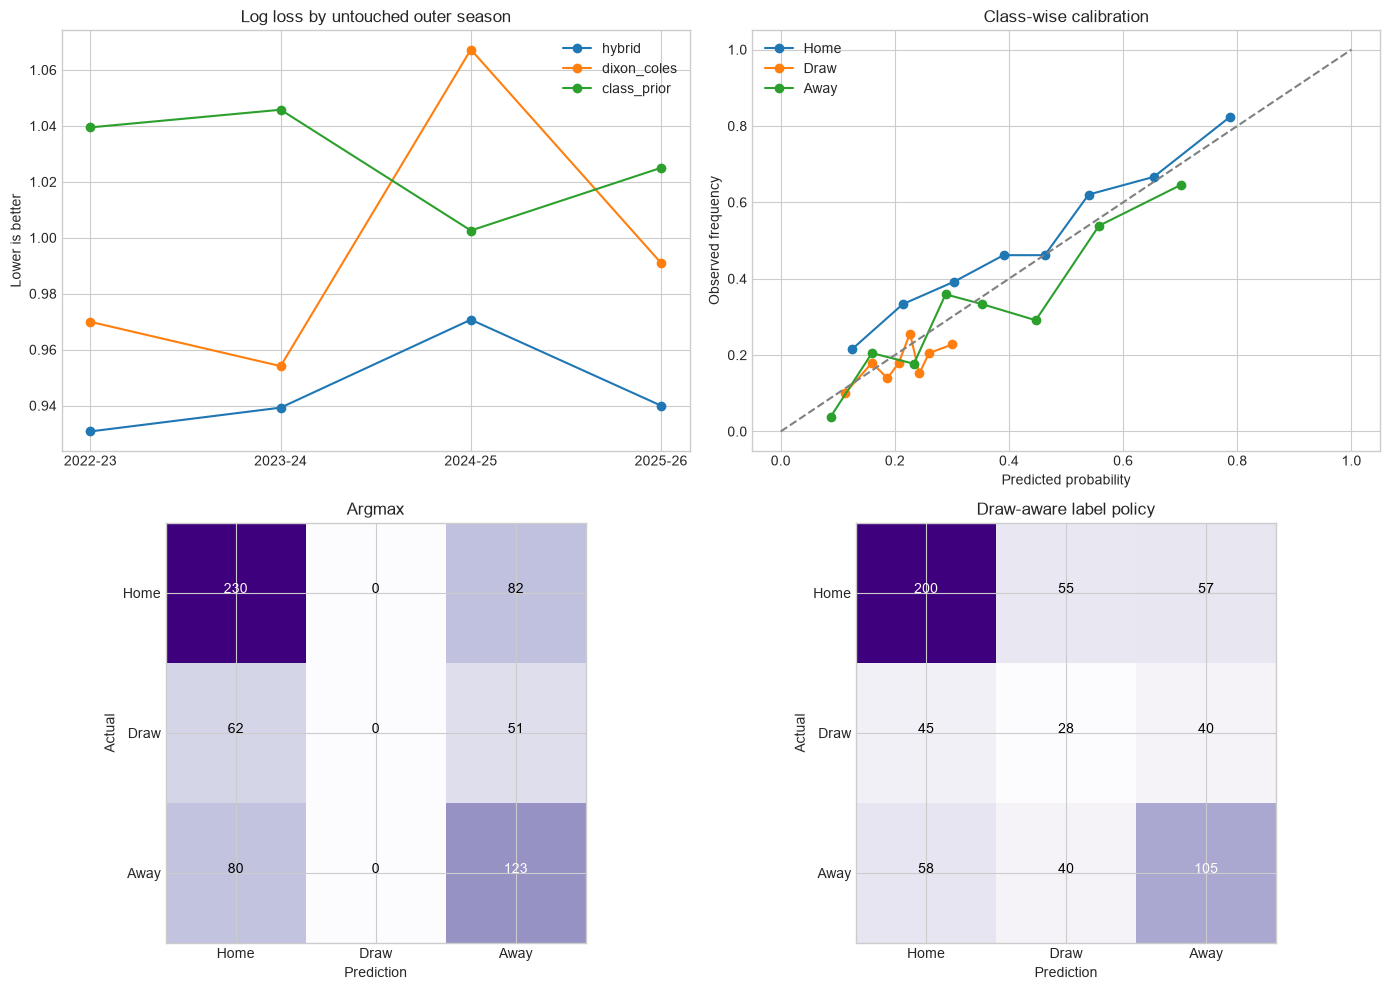

In [9]:
aggregate_rows=[];class_rows=[]
for name,f in outer_predictions.groupby('model'):
    p=f[['p_home','p_draw','p_away']].to_numpy();y=target(f)
    aggregate_rows.append(dict(model=name,n=len(f),**metrics(y,p,f.prediction.to_numpy())))
    for k,label in enumerate(LABELS):
        class_rows.append(dict(model=name,class_name=label,observed_rate=np.mean(y==k),
            mean_probability=np.mean(p[:,k]),ece=ece_binary(y==k,p[:,k]),brier=np.mean(((y==k)-p[:,k])**2)))
aggregate=pd.DataFrame(aggregate_rows);classwise=pd.DataFrame(class_rows)
display(aggregate);display(classwise.loc[classwise.model=='hybrid'])

def bootstrap_report(f,reference=None,repeats=BOOTSTRAP_REPEATS):
    f=f.sort_values('match_id').reset_index(drop=True);y=target(f)
    p=f[['p_home','p_draw','p_away']].to_numpy();pred=f.prediction.to_numpy()
    ref=None
    if reference is not None:
        reference=reference.set_index('match_id').loc[f.match_id]
        ref=reference[['p_home','p_draw','p_away']].to_numpy();rp=reference.prediction.to_numpy()
    groups={s:[np.asarray(v) for v in sf.groupby('date').groups.values()] for s,sf in f.groupby('season')}
    keys=['accuracy','macro_f1','balanced_accuracy','log_loss','brier','ece','draw_recall','draw_f1','draw_ece']
    rng=np.random.default_rng(42);samples=[]
    point=metrics(y,p,pred)
    if ref is not None:
        rm=metrics(y,ref,rp);point={k:point[k]-rm[k] for k in keys}
    for _ in range(repeats):
        ix=np.concatenate([np.concatenate([blocks[j] for j in rng.integers(0,len(blocks),len(blocks))]) for blocks in groups.values()])
        v=metrics(y[ix],p[ix],pred[ix])
        if ref is not None:
            r=metrics(y[ix],ref[ix],rp[ix]);v={k:v[k]-r[k] for k in keys}
        samples.append([v[k] for k in keys])
    samples=np.asarray(samples)
    return pd.DataFrame([dict(metric=k,value=point[k],lower95=np.quantile(samples[:,i],.025),upper95=np.quantile(samples[:,i],.975)) for i,k in enumerate(keys)])

hybrid=outer_predictions.loc[outer_predictions.model=='hybrid']
policy=outer_predictions.loc[outer_predictions.model=='hybrid_draw_policy']
dc_predictions=outer_predictions.loc[outer_predictions.model=='dixon_coles']
confidence_intervals=bootstrap_report(hybrid)
policy_intervals=bootstrap_report(policy)
paired_vs_dc=bootstrap_report(hybrid,dc_predictions)
display(confidence_intervals);display(paired_vs_dc)

from sklearn.calibration import calibration_curve
fig,axes=plt.subplots(2,2,figsize=(14,10))
for label in ['hybrid','dixon_coles','class_prior']:
    f=outer_metrics.loc[outer_metrics.model==label];axes[0,0].plot(f.season,f.log_loss,'o-',label=label)
axes[0,0].legend();axes[0,0].set(title='Log loss by untouched outer season',ylabel='Lower is better')
p=hybrid[['p_home','p_draw','p_away']].to_numpy();y=target(hybrid)
for k,label in enumerate(LABELS):
    observed,estimated=calibration_curve(y==k,p[:,k],n_bins=8,strategy='quantile')
    axes[0,1].plot(estimated,observed,'o-',label=label)
axes[0,1].plot([0,1],[0,1],'--',color='gray');axes[0,1].legend()
axes[0,1].set(title='Class-wise calibration',xlabel='Predicted probability',ylabel='Observed frequency')
for ax,f,title in [(axes[1,0],hybrid,'Argmax'),(axes[1,1],policy,'Draw-aware label policy')]:
    cm=confusion_matrix(target(f),f.prediction,labels=[0,1,2]);ax.imshow(cm,cmap='Purples')
    for i in range(3):
        for j in range(3):ax.text(j,i,str(cm[i,j]),ha='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
    ax.set(title=title,xticks=range(3),yticks=range(3),xticklabels=LABELS,yticklabels=LABELS,xlabel='Prediction',ylabel='Actual')
plt.tight_layout();plt.savefig(OUTPUT_DIR/'evaluation_v4.png',dpi=150);plt.show()



### Ablation dan grouped permutation

In [10]:
# Multi-season ablation, fixed estimator. No post-test feature selection.
variants={'full':FEATURES,'no_h2h':[c for c in FEATURES if c not in H2H],
    'no_draw_signals':[c for c in FEATURES if c not in DRAW_SIGNALS],
    'no_stage_leg':[c for c in FEATURES if c not in CONTEXT],
    'latest_six_prematch':['neutral','home_elo_pre','away_elo_pre','elo_diff_pre']+H2H}
ablation_rows=[]
for season in OUTER_SEASONS:
    cal_season=SEASONS[SEASONS.index(season)-1]
    tr=professional.loc[professional.season<cal_season];ca=professional.loc[professional.season==cal_season];te=professional.loc[professional.season==season]
    for name,columns in variants.items():
        m=fit_model(tr,'xgb_full',columns);pc=predict_model(m,ca);pt=predict_model(m,te)
        cal=fit_calibration(target(ca),pc,'temperature');pt=apply_calibration(cal,pt)
        ablation_rows.append(dict(season=season,variant=name,feature_count=len(columns),**metrics(target(te),pt)))
    print('Ablation ready:',season,flush=True)
ablation=pd.DataFrame(ablation_rows)
ablation['delta_log_loss_vs_full']=ablation.log_loss-ablation.season.map(ablation.loc[ablation.variant=='full'].set_index('season').log_loss)
ablation_summary=ablation.groupby('variant')[['log_loss','brier','macro_f1','draw_ap','delta_log_loss_vs_full']].agg(['mean','std'])
display(ablation_summary)

# Grouped permutation on each held-out season: shuffle correlated inputs together.
permutation_rows=[];rng=np.random.default_rng(9026)
groups={'elo':[c for c in FEATURES if 'elo' in c],'h2h':H2H,'draw_proxies':DRAW_SIGNALS,
    'stage_leg':CONTEXT,'recent_form':[c for c in FEATURES if c not in set(H2H+DRAW_SIGNALS+CONTEXT) and 'elo' not in c]}
for season,pipe in pipelines.items():
    f=professional.loc[professional.season==season].copy();y=target(f);base=predict_pipeline(pipe,f)[0]
    loss=log_loss(y,base,labels=[0,1,2])
    for group,cols in groups.items():
        deltas=[]
        for _ in range(5):
            shuffled=f.copy();order=rng.permutation(len(f));shuffled[cols]=f[cols].to_numpy()[order]
            p=predict_pipeline(pipe,shuffled)[0];deltas.append(log_loss(y,p,labels=[0,1,2])-loss)
        permutation_rows.append(dict(season=season,group=group,delta_log_loss_mean=np.mean(deltas),std=np.std(deltas)))
permutation_table=pd.DataFrame(permutation_rows)
display(permutation_table.groupby('group').delta_log_loss_mean.agg(['mean','std']))

agg=aggregate.set_index('model');ci_dc=paired_vs_dc.set_index('metric')
assessment=dict(execution_valid=True,leakage_checks_passed=True,
    log_loss_better_than_class_prior=bool(agg.loc['hybrid','log_loss']<agg.loc['class_prior','log_loss']),
    log_loss_better_than_dc=bool(agg.loc['hybrid','log_loss']<agg.loc['dixon_coles','log_loss']),
    paired_log_loss_ci_below_zero=bool(ci_dc.loc['log_loss','upper95']<0),
    draw_policy_recall=float(agg.loc['hybrid_draw_policy','draw_recall']),
    draw_policy_accuracy_cost=float(agg.loc['hybrid','accuracy']-agg.loc['hybrid_draw_policy','accuracy']),
    prospective_validation_completed=False)
display(pd.Series(assessment,name='Evidence check').to_frame())


Ablation ready: 2022-23


Ablation ready: 2023-24


Ablation ready: 2024-25


Ablation ready: 2025-26


log_loss         brier        macro_f1        draw_ap  \
                        mean    std   mean    std     mean    std    mean   
variant                                                                     
full                  0.9320 0.0189 0.5492 0.0110   0.4393 0.0251  0.2536   
latest_six_prematch   0.9547 0.0160 0.5626 0.0106   0.4359 0.0287  0.2683   
no_draw_signals       0.9303 0.0176 0.5482 0.0101   0.4461 0.0241  0.2677   
no_h2h                0.9368 0.0221 0.5521 0.0137   0.4298 0.0088  0.2367   
no_stage_leg          0.9323 0.0200 0.5495 0.0117   0.4376 0.0239  0.2526   

                           delta_log_loss_vs_full         
                       std                   mean    std  
variant                                                   
full                0.0710                 0.0000 0.0000  
latest_six_prematch 0.0746                 0.0227 0.0155  
no_draw_signals     0.0703                -0.0017 0.0023  
no_h2h              0.0574                 0.0049 0.0040  
no_stage_leg        0.0674                 0.0003 0.0030

,mean,std
group,,
draw_proxies,-0.0001,0.0025
elo,0.0525,0.0381
h2h,0.0008,0.0024
recent_form,0.0134,0.0103
stage_leg,0.0003,0.0010


,Evidence check
execution_valid,True
leakage_checks_passed,True
log_loss_better_than_class_prior,True
log_loss_better_than_dc,True
paired_log_loss_ci_below_zero,True
draw_policy_recall,0.2478
draw_policy_accuracy_cost,0.0318
prospective_validation_completed,False


## 6. Prediksi, export dan pemeriksaan reload

Ubah klub dan tanggal pada contoh `forecast`. Tanggal harus sesudah histori state. Hasil 1X2 dan label draw-aware dipisahkan. Distribusi skor diselaraskan ke 1X2 agar tampilan konsisten; BTTS/Over–Under belum dikalibrasi secara tersendiri.

Bundle memakai schema v4 dan perlu adapter Flask yang sesuai. State klub dan kalibrator disimpan, model XGBoost juga diekspor sebagai booster JSON. Ekspor diuji dengan memuat kembali bundle dan membandingkan hasil prediksi.

In [11]:
production,production_split,production_search,production_policy_search=fit_pipeline('future')

def forecast(pipe,state,home,away,date,stage='league_phase',leg='not_applicable',neutral=0):
    if home==away:raise ValueError('Pilih dua klub berbeda.')
    if home not in state['teams'] or away not in state['teams']:raise ValueError('Klub belum tersedia dalam histori.')
    date=pd.Timestamp(date)
    if date<=state['last_date']:raise ValueError('Tanggal prediksi harus setelah histori state. Gunakan state snapshot untuk backtest.')
    values=match_features(state,home,away,date,stage,leg,neutral)
    row=pd.DataFrame([values]);row['home_team']=home;row['away_team']=away
    p,raw,parts,decisions=predict_pipeline(pipe,row);p=p[0]
    matrix=pipe['dc'].score_matrix(home,away,neutral=int(neutral),max_goals=MAX_GOALS)
    h,a=np.indices(matrix.shape);masks=[h>a,h==a,h<a]
    # Preserve DC's within-outcome score shape while making 1X2 totals consistent.
    for k,mask in enumerate(masks):matrix[mask]*=p[k]/matrix[mask].sum()
    assert np.allclose([matrix[m].sum() for m in masks],p)
    top=np.argsort(matrix,axis=None)[-10:][::-1]
    result=dict(home_team=home,away_team=away,date=str(date.date()),stage=stage,leg=leg,
        one_x_two=dict(zip(['home','draw','away'],map(float,p))),
        probability_argmax=LABELS[int(p.argmax())],recommended_outcome=LABELS[int(decisions[0])],
        draw_multiplier=pipe['multiplier'],
        top_scores=[dict(score=f'{i}-{j}',probability=float(matrix[i,j])) for i,j in [np.unravel_index(k,matrix.shape) for k in top]],
        expected_goals=dict(home=float((matrix*h).sum()),away=float((matrix*a).sum())),
        btts_yes=float(matrix[(h>0)&(a>0)].sum()),
        over_under={f'over_{v}':float(matrix[h+a>v].sum()) for v in [.5,1.5,2.5,3.5,4.5,5.5]},
        score_method='Dixon-Coles reconciled to calibrated 1X2; goal markets not independently calibrated',
        data_until=str(state['last_date'].date()))
    return result,matrix

PREDICTION_DATE=(matches.date.max()+pd.Timedelta(days=1)).date().isoformat()
example,score_matrix=forecast(production,final_state,'Real Madrid','FC Barcelona',PREDICTION_DATE)
display(pd.Series({k:v for k,v in example.items() if k not in ['top_scores','over_under']}).to_frame('Prediction'))
display(pd.DataFrame(example['top_scores']).style.format({'probability':'{:.2%}'}))

tables={'outer_predictions':outer_predictions,'outer_metrics':outer_metrics,'aggregate':aggregate,
    'classwise_calibration':classwise,'split_audit':split_audit,'inner_search':inner_search,
    'draw_policy_search':policy_search,'confidence_intervals':confidence_intervals,
    'policy_intervals':policy_intervals,'paired_vs_dc':paired_vs_dc,'ablation':ablation,
    'permutation_importance':permutation_table,'production_search':production_search,
    'production_policy_search':production_policy_search}
for name,table in tables.items():table.to_csv(OUTPUT_DIR/f'v4_{name}.csv',index=False)
ablation_summary.to_csv(OUTPUT_DIR/'v4_ablation_summary.csv')
dc=production['dc'];dc_state={k:getattr(dc,k) for k in ['xi','ridge','rho_bounds','teams_',
    'team_idx_','log_attack_','log_defense_','log_home_advantage_','rho_']}
bundle=dict(schema_version='matchiq-ucl-v4-audited',models=production['models'],config=production['config'],
    calibration=production['calibration'],multiplier=production['multiplier'],dc_state=dc_state,
    team_state=final_state,feature_columns=FEATURES,production_split=production_split,
    versions=dict(python=platform.python_version(),sklearn=sklearn.__version__,xgboost=xgboost.__version__))
joblib.dump(bundle,OUTPUT_DIR/'matchiq_ucl_v4_bundle.joblib',compress=3)
for name,b in production['models'].items():
    for i,m in enumerate(b['models']):
        if hasattr(m,'get_booster'):m.get_booster().save_model(OUTPUT_DIR/f'{name}_{i}.json')

dataset_bytes = DATA_ZIP_PATH.read_bytes() if DATA_ZIP_PATH is not None else b''.join(path.read_bytes() for path in [MATCHES_PATH, ALL_MATCHES_PATH, TEAMS_PATH, ALIASES_PATH])
report=dict(schema='matchiq-ucl-v4-audited',dataset_sha256=hashlib.sha256(dataset_bytes).hexdigest(),
    input_notebook='notebooks/MatchIQ_UCL_v4_Audited.ipynb',
    previous_report_metrics_valid_for_prematch=False,
    audit_findings=['Current half-time scores leaked into the pre-match model.',
        'Inference substituted 0.5 goals for actual half-time scores used in training.',
        'Production Elo selected the home rating even for away appearances, before final update.',
        'Isotonic experiment was not applied/exported with production inference.',
        'cv=5 used non-temporal calibration; notebook claims were not verified performance guarantees.'],
    counts=dict(matches=len(matches),outer_matches=len(hybrid),seasons=len(SEASONS)),
    assessment=assessment,aggregate=aggregate.to_dict('records'),outer_metrics=outer_metrics.to_dict('records'),
    splits=split_audit.to_dict('records'),paired_vs_dc=paired_vs_dc.to_dict('records'),
    production_split=production_split,versions=bundle['versions'],
    limitations=['Previously viewed seasons are historical research backtests; confirm on genuinely new fixtures.',
        'No injury, lineup, transfer, domestic-league or market-odds data are included.',
        'Goal-market calibration and exact-score accuracy require separate evaluation.',
        'Ablation and permutation diagnostics do not establish causality.',
        'Bootstrap conditions on observed seasons/fitted models; it does not include full model-selection uncertainty.',
        'Base coefficients freeze before final calibration; rolling history updates only from already completed games.'])
(OUTPUT_DIR/'v4_evaluation.json').write_text(json.dumps(report,indent=2),encoding='utf-8')
(OUTPUT_DIR/'sample_prediction.json').write_text(json.dumps(example,indent=2),encoding='utf-8')

# Validate serialized inference, not only whether files exist.
reloaded=joblib.load(OUTPUT_DIR/'matchiq_ucl_v4_bundle.joblib')
restored_dc=DixonColesModel()
for key,value in reloaded['dc_state'].items():setattr(restored_dc,key,value)
restored=dict(models=reloaded['models'],config=reloaded['config'],calibration=reloaded['calibration'],
    multiplier=reloaded['multiplier'],dc=restored_dc)
check,_=forecast(restored,reloaded['team_state'],'Real Madrid','FC Barcelona',PREDICTION_DATE)
assert np.allclose(list(check['one_x_two'].values()),list(example['one_x_two'].values()))
allp=outer_predictions[['p_home','p_draw','p_away']].to_numpy()
assert np.isfinite(allp).all() and np.allclose(allp.sum(1),1)
assert not outer_predictions.duplicated(['model','match_id']).any()
OUTPUT_ZIP=WORK_ROOT/'matchiq_ucl_v4_audited_outputs.zip'
with zipfile.ZipFile(OUTPUT_ZIP,'w',zipfile.ZIP_DEFLATED) as z:
    for file in sorted(OUTPUT_DIR.iterdir()):z.write(file,file.name)
with zipfile.ZipFile(OUTPUT_ZIP) as z:assert z.testzip() is None
print('PASS: export/reload parity, probability sums, unique audit rows, output ZIP integrity.')
print('Output:',OUTPUT_ZIP)
if IN_COLAB:
    from google.colab import files
    files.download(str(OUTPUT_ZIP))


OOF ready: 2024-25


,Prediction
home_team,Real Madrid
away_team,FC Barcelona
date,2026-05-31
stage,league_phase
leg,not_applicable
one_x_two,"{'home': 0.4505449253530452, 'draw': 0.1745380..."
probability_argmax,Home
recommended_outcome,Home
draw_multiplier,1.9000
expected_goals,"{'home': 2.4839238311354133, 'away': 2.1177151..."


,score,probability
0,2-2,6.87%
1,1-2,6.59%
2,2-3,5.74%
3,2-1,5.56%
4,3-1,5.03%
5,3-2,4.84%
6,1-1,4.62%
7,1-3,4.23%
8,3-3,3.98%
9,4-1,3.41%


PASS: export/reload parity, probability sums, unique audit rows, output ZIP integrity.
Output: D:\Projects\MatchIQ\outputs\ucl_v4_notebook\matchiq_ucl_v4_audited_outputs.zip


## Batas klaim dan referensi

Notebook mengukur kelayakan dari hasil yang benar-benar dihitung; status eksekusi PASS bukan sertifikasi bahwa model sudah unggul. Pertandingan baru, data lineup/cedera/performa domestik, dan evaluasi live masih diperlukan untuk menilai manfaat aplikasi nyata. Semua angka sebelum hasil uji dicetak merupakan konfigurasi, bukan janji performa.

- [scikit-learn: data leakage dan preprocessing konsisten](https://scikit-learn.org/stable/common_pitfalls.html)
- [scikit-learn: probability calibration dan data kalibrasi terpisah](https://scikit-learn.org/stable/modules/calibration.html)
